# **Projet : Prédiction de la valeur du VKOSPI**

Ce projet s'inscrit dans le cadre du cours de **Machine Learning** dispensé par Théo Lopès-Quintas à l'Université Paris Dauphine.

---

# **Auteurs**
HUYEN Joëlle<br>
HUYEN Julie<br>
JIANG Qinming<br>
SARFATI Léonore<br>
ZAFIZARA-BENETRIX Nathan<br>

---

## **Objectif**
L'objectif est de prédire la valeur de l'indice de volatilité implicite coréen VKOSPI, en utilisant des algorithmes de Machine Learning vus en cours.
La métrique de référence sera la RSME.

---

# [**Description du Dataset VKOSPI**](https://www.kaggle.com/datasets/ninetyninenewton/vkospi/data)

Le dataset représente les **données de marché** pour l'indice **VKOSPI**, l'équivalent coréen de l'indice de volatilité implicite **VIX** aux États-Unis. Chaque ligne du dataset correspond à un **jour de trading**, excluant les week-ends et les jours fériés. Les colonnes fournissent diverses informations sur les **transactions et les positions** des options et des futures sur l'indice **KOSPI200**, qui est l'actif sous-jacent du VKOSPI.

---

## **Description des Colonnes**

| **Nom de la colonne**           | **Description**                                                                                |
|---------------------------------|:-----------------------------------------------------------------------------------------------|
| **`Date`**                      | La date du jour de trading.                                                                    |
| **`VKOSPI`**                    | La valeur de l'indice de volatilité implicite **VKOSPI** pour ce jour.                         |
| **`KOSPI200`**                  | La valeur de l'indice **KOSPI200** pour ce jour.                                               |
| **`Open_interest`**             | Le nombre total de **contrats d'options ouverts** (non réglés) pour ce jour.                   |
| **`For_KOSPI_Netbuying_Amount`**| Le **montant net acheté** par les étrangers pour l'indice **KOSPI200** *(Prix × Quantité)*.    |
| **`For_Future_Netbuying_Quantity`** | La **quantité nette achetée** par les étrangers pour les **futures** de **KOSPI200**.          |
| **`For_Call_Netbuying_Quantity`**   | La **quantité nette achetée** par les étrangers pour les **options d'achat (call)**.           |
| **`For_Put_Netbuying_Quantity`**    | La **quantité nette achetée** par les étrangers pour les **options de vente (put)**.           |
| **`Indiv_Future_Netbuying_Quantity`** | La **quantité nette achetée** par les **individus** pour les **futures**.                      |
| **`Indiv_Call_Netbuying_Quantity`**   | La **quantité nette achetée** par les **individus** pour les **options d'achat (call)**.       |
| **`Indiv_Put_Netbuying_Quantity`**    | La **quantité nette achetée** par les **individus** pour les **options de vente (put)**.       |
| **`PCRatio`**                  | Le **ratio Put-Call**, rapport entre le **volume des options put** et **call** *(Put/Call)*.   |
| **`Day_till_expiration`**      | Le **nombre de jours restants** jusqu'à la **date d'expiration** des options.                  |
| **`Day_of_a_week`**      | Le **jour de la semaine** correspondant à la **date de trading** (ex: Lundi, Mardi, etc.).                 |

---

## **Notes supplémentaires :**
- Les données couvrent uniquement les jours de trading actifs.
- Le VKOSPI est un indicateur clé de la **volatilité implicite** du marché coréen.
- Les valeurs nettes d'achat pour les étrangers et les individus offrent un aperçu des stratégies de marché.

---

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

## **Exploration et préparation des données**

Commençons sans plus attendre par importer les données et les observer !

In [57]:
df = pd.read_csv("options_KR.csv")
df.head()

,Date,VKOSPI,KOSPI200,Open_interest,For_KOSPI_Netbuying_Amount,For_Future_Netbuying_Quantity,For_Call_Netbuying_Quantity,For_Put_Netbuying_Quantity,Indiv_Future_Netbuying_Quantity,Indiv_Call_Netbuying_Quantity,Indiv_Put_Netbuying_Quantity,PCRatio,Day_till_expiration,Day_of_a_week
0,2009-06-02,33.45,180.90,4377777,4.940000e+11,-4953,-24646,6581,1228,-466,31336,0.94,7,Tue
1,2009-06-03,32.66,180.47,4562690,-8.997074e+10,47,-57128,46851,399,127709,-22259,0.93,6,Wed
2,2009-06-04,32.56,180.31,4827524,-1.090000e+11,-7666,-2000,48883,5744,262558,10367,0.87,5,Thu
3,2009-06-05,32.95,175.75,5022921,9.842024e+10,969,64792,27196,-1688,79789,113935,0.89,4,Fri
4,2009-06-08,30.41,177.77,5293996,4.329179e+10,5797,10995,23123,-5534,97154,146244,0.81,3,Mon


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             2580 non-null   object 
 1   VKOSPI                           2580 non-null   float64
 2   KOSPI200                         2580 non-null   float64
 3   Open_interest                    2580 non-null   int64  
 4   For_KOSPI_Netbuying_Amount       2580 non-null   float64
 5   For_Future_Netbuying_Quantity    2580 non-null   int64  
 6   For_Call_Netbuying_Quantity      2580 non-null   int64  
 7   For_Put_Netbuying_Quantity       2580 non-null   int64  
 8   Indiv_Future_Netbuying_Quantity  2580 non-null   int64  
 9   Indiv_Call_Netbuying_Quantity    2580 non-null   int64  
 10  Indiv_Put_Netbuying_Quantity     2580 non-null   int64  
 11  PCRatio                          2580 non-null   float64
 12  Day_till_expiration 

On constate d'ores et déjà que la colonne "Date" est mal typée. On va immédiatemment la remettre en forme pour ne pas avoir de mauvaises surprises par la suite.

In [59]:
df['Date'] = pd.to_datetime(df['Date'])

Ensuite, on souhaite avoir une vue plus statistique du dataset. On ne prendra pas en compte que les données numériques (on ignore les colonnes liées aux dates pour le moment).

In [60]:
df.describe()

,Date,VKOSPI,KOSPI200,Open_interest,For_KOSPI_Netbuying_Amount,For_Future_Netbuying_Quantity,For_Call_Netbuying_Quantity,For_Put_Netbuying_Quantity,Indiv_Future_Netbuying_Quantity,Indiv_Call_Netbuying_Quantity,Indiv_Put_Netbuying_Quantity,PCRatio,Day_till_expiration
count,2580,2580.000000,2580.000000,2.580000e+03,2.580000e+03,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000
mean,2014-08-09 04:11:43.255813888,16.744302,259.246508,2.303927e+06,2.889290e+10,10.226744,2727.117829,14117.202326,4.820930,16000.406589,6695.945736,0.954837,9.982946
min,2009-06-02 00:00:00,9.720000,174.320000,2.242960e+05,-1.310000e+12,-20745.000000,-174455.000000,-183760.000000,-11879.000000,-179929.000000,-151533.000000,0.280000,0.000000
25%,2011-12-25 06:00:00,13.087500,243.750000,1.013118e+06,-1.130000e+11,-2164.750000,-2863.250000,1836.000000,-1209.500000,-2574.000000,-13051.250000,0.850000,5.000000
50%,2014-08-04 12:00:00,15.305000,257.310000,1.879194e+06,2.221070e+10,31.000000,1780.000000,9257.500000,-13.000000,4984.000000,-2065.500000,0.950000,10.000000
75%,2017-03-17 18:00:00,18.772500,271.570000,3.236718e+06,1.670000e+11,2221.500000,7435.250000,23097.500000,1213.500000,17872.250000,9729.000000,1.050000,15.000000
max,2019-11-07 00:00:00,50.110000,338.830000,9.134484e+06,1.720000e+12,20265.000000,152445.000000,228939.000000,10325.000000,908263.000000,919563.000000,1.790000,26.000000
std,NaN,5.327865,29.034358,1.578398e+06,2.560887e+11,3953.221118,19549.308255,25202.453076,2126.388898,53037.030365,59832.131764,0.170583,6.293434


On commence par regarder ce que l'on veut prédire : l'indice VKOSPI. On note un grand écart de valeur entre le troisième quartile et le maximum : cela peut se traduire par une grande variance dans les performances d'une validation croisée par exemple.

Pour les colonnes suivantes : "For_Future_Netbuying_Quantity", "For_Call_Netbuying_Quantity", "For_Put_Netbuying_Quantity",	"Indiv_Future_Netbuying_Quantity", "Indiv_Call_Netbuying_Quantity",	"Indiv_Put_Netbuying_Quantity", on remarque des écarts gigantesques entre le premier quartile et le minimum, puis entre le troisième quartile et le maximum. Cela suggère la présence d'outliers, qu'on va essayer de mettre en évidence !

Maintenant, nous allons essayer d'observer la distribution de chaque colonne pour vérifier la qualité des données : est-ce qu'il y a des valeurs qui sortent du lot dans le dataset ?

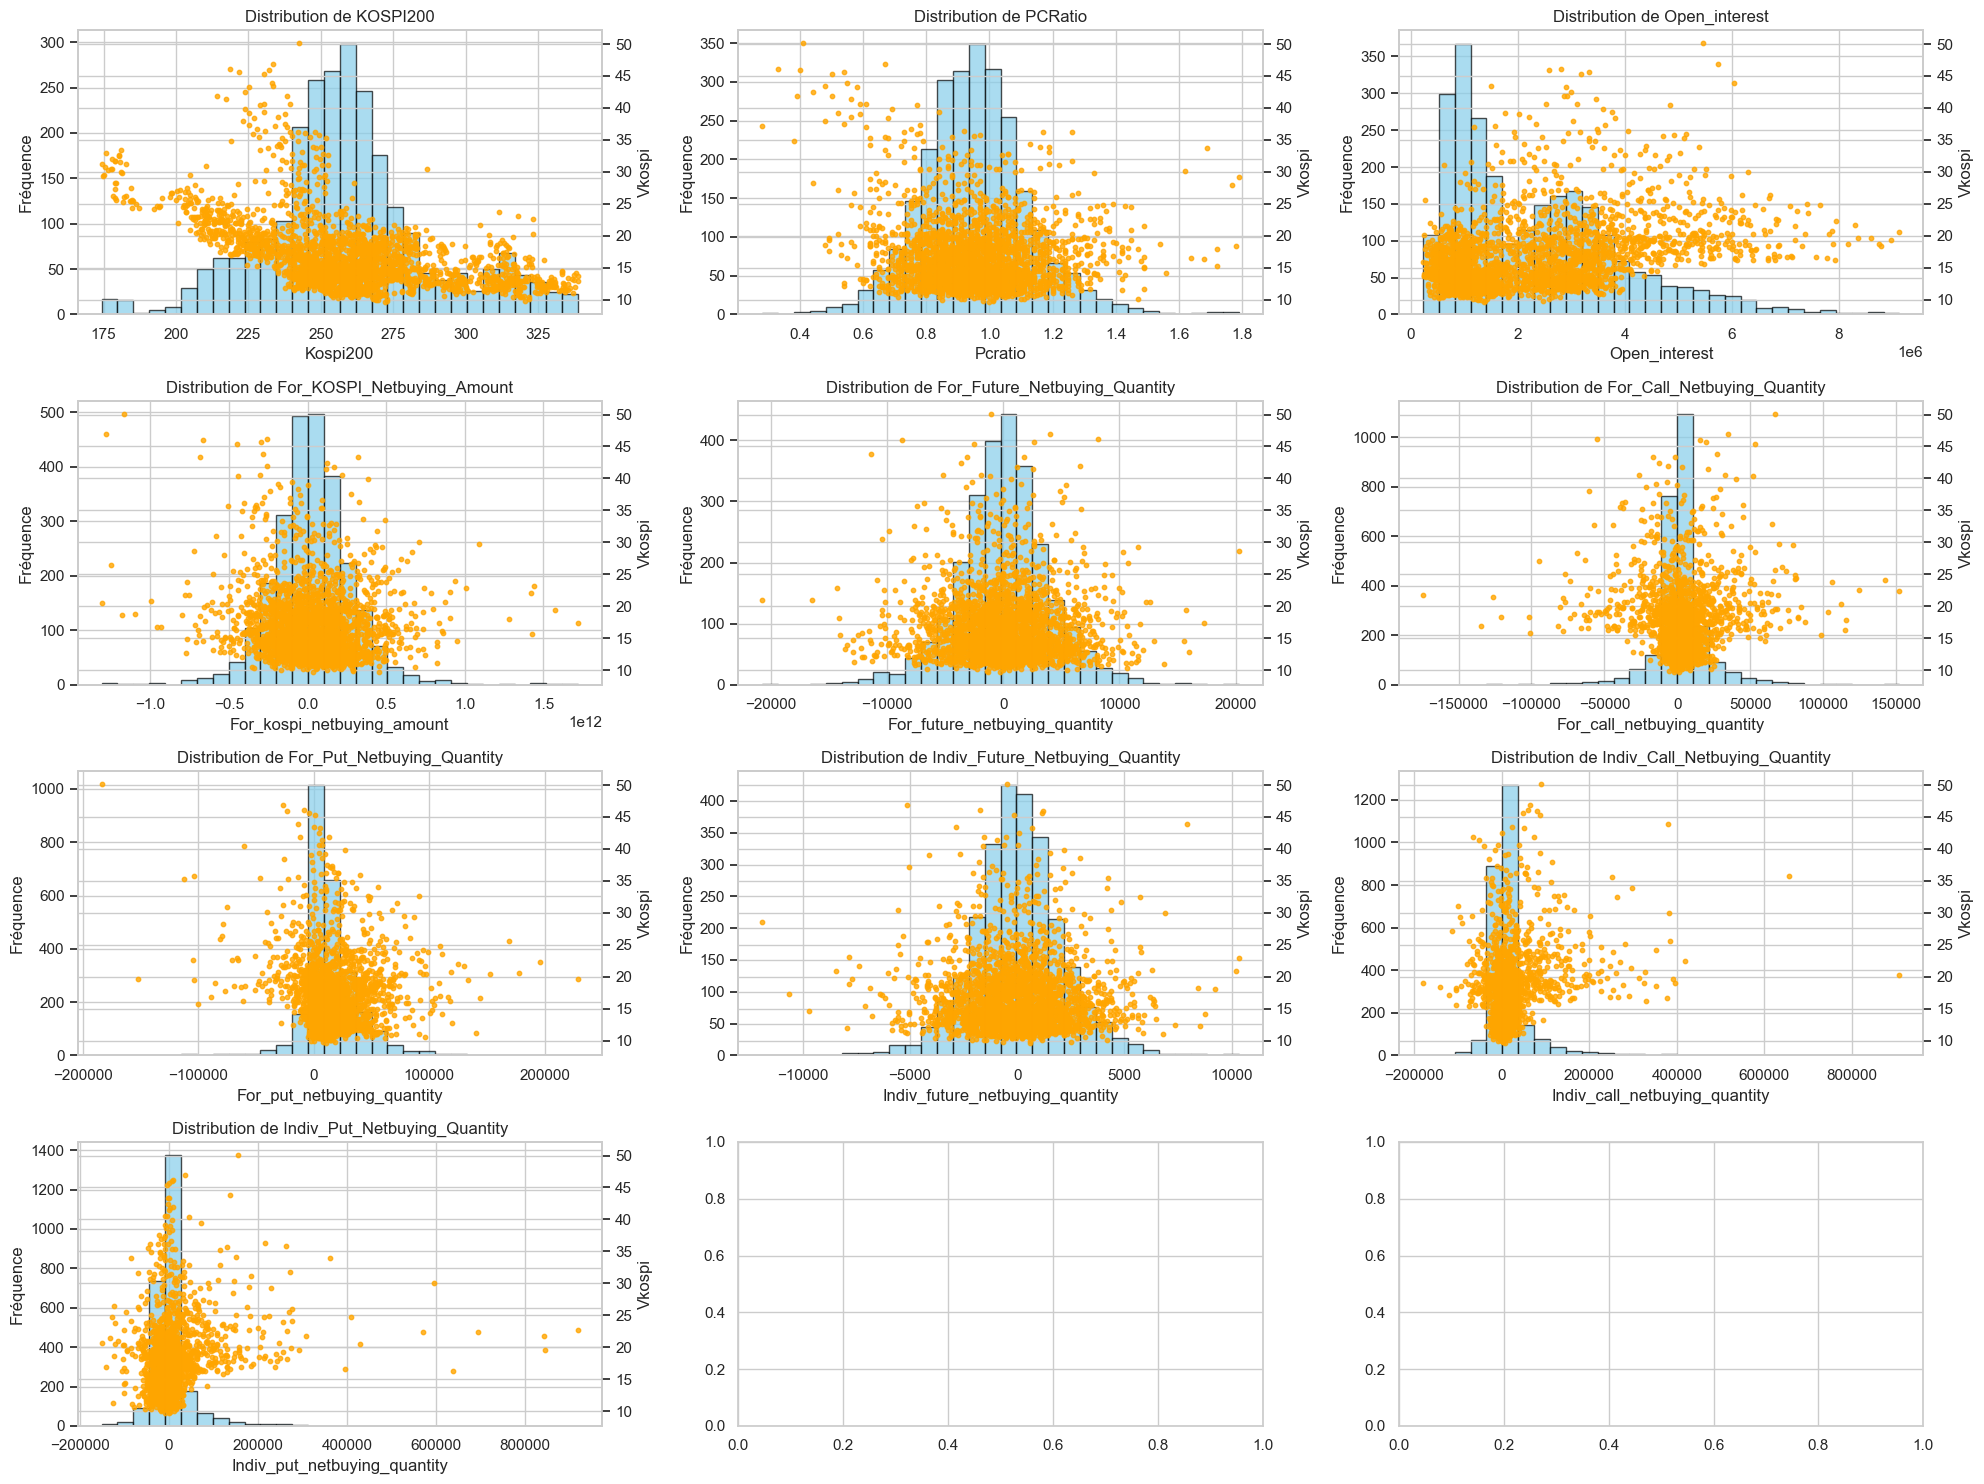

In [61]:
import matplotlib.pyplot as plt

def explore_columns_combined(df, columns, target_column, alpha=0.8, figsize=(20, 15)):
    n = len(columns)
    rows = (n + 2) // 3  # 3 colonnes par ligne

    fig, axes = plt.subplots(rows, 3, figsize=figsize)
    axes = axes.flatten()

    for i, column in enumerate(columns):
        # Histogramme avec axe principal
        axes[i].hist(df[column], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i].set_xlabel(column.capitalize())
        axes[i].set_title(f"Distribution de {column}")
        axes[i].set_ylabel("Fréquence")  # Axe Y pour l'histogramme

        # Scatter plot avec un second axe Y
        ax2 = axes[i].twinx()
        ax2.scatter(df[column], df[target_column], alpha=alpha, color='orange', s=10)
        ax2.set_ylabel(target_column.capitalize())  # Axe Y pour VKOSPI

    plt.tight_layout()
    plt.show()

# Colonnes à explorer
columns_to_explore = [
    "KOSPI200", "PCRatio", "Open_interest", "For_KOSPI_Netbuying_Amount",
    "For_Future_Netbuying_Quantity", "For_Call_Netbuying_Quantity",
    "For_Put_Netbuying_Quantity", "Indiv_Future_Netbuying_Quantity",
    "Indiv_Call_Netbuying_Quantity", "Indiv_Put_Netbuying_Quantity",
]

explore_columns_combined(df, columns_to_explore, "VKOSPI")


A vue d'oeil, on remarque en effet certaines valeurs qui sortent du lot. De plus, ces observations ne sont pas dans la tendance que l'on observe avec la variable cible. Nous allons donc les supprimer car elles risquent d'empêcher notre modèle de bien apprendre !

In [62]:
print("Taille avant : %d" % df.shape[0])
df = df.loc[df["Indiv_Put_Netbuying_Quantity"] < 300000, ]
df = df.loc[df["Indiv_Call_Netbuying_Quantity"] < 300000, ]
df = df.loc[(df["Indiv_Future_Netbuying_Quantity"] > -8000) & (df["Indiv_Future_Netbuying_Quantity"] < 8000), ]
df = df.loc[(df["For_Put_Netbuying_Quantity"] > -100000) & (df["Indiv_Future_Netbuying_Quantity"] < 150000), ]
df = df.loc[(df["For_Call_Netbuying_Quantity"] > -100000) & (df["For_Call_Netbuying_Quantity"] < 100000), ]
df = df.loc[(df["For_KOSPI_Netbuying_Amount"] > -1), ]

print("Taille après : %d" % df.shape[0])

Taille avant : 2580
Taille après : 1387


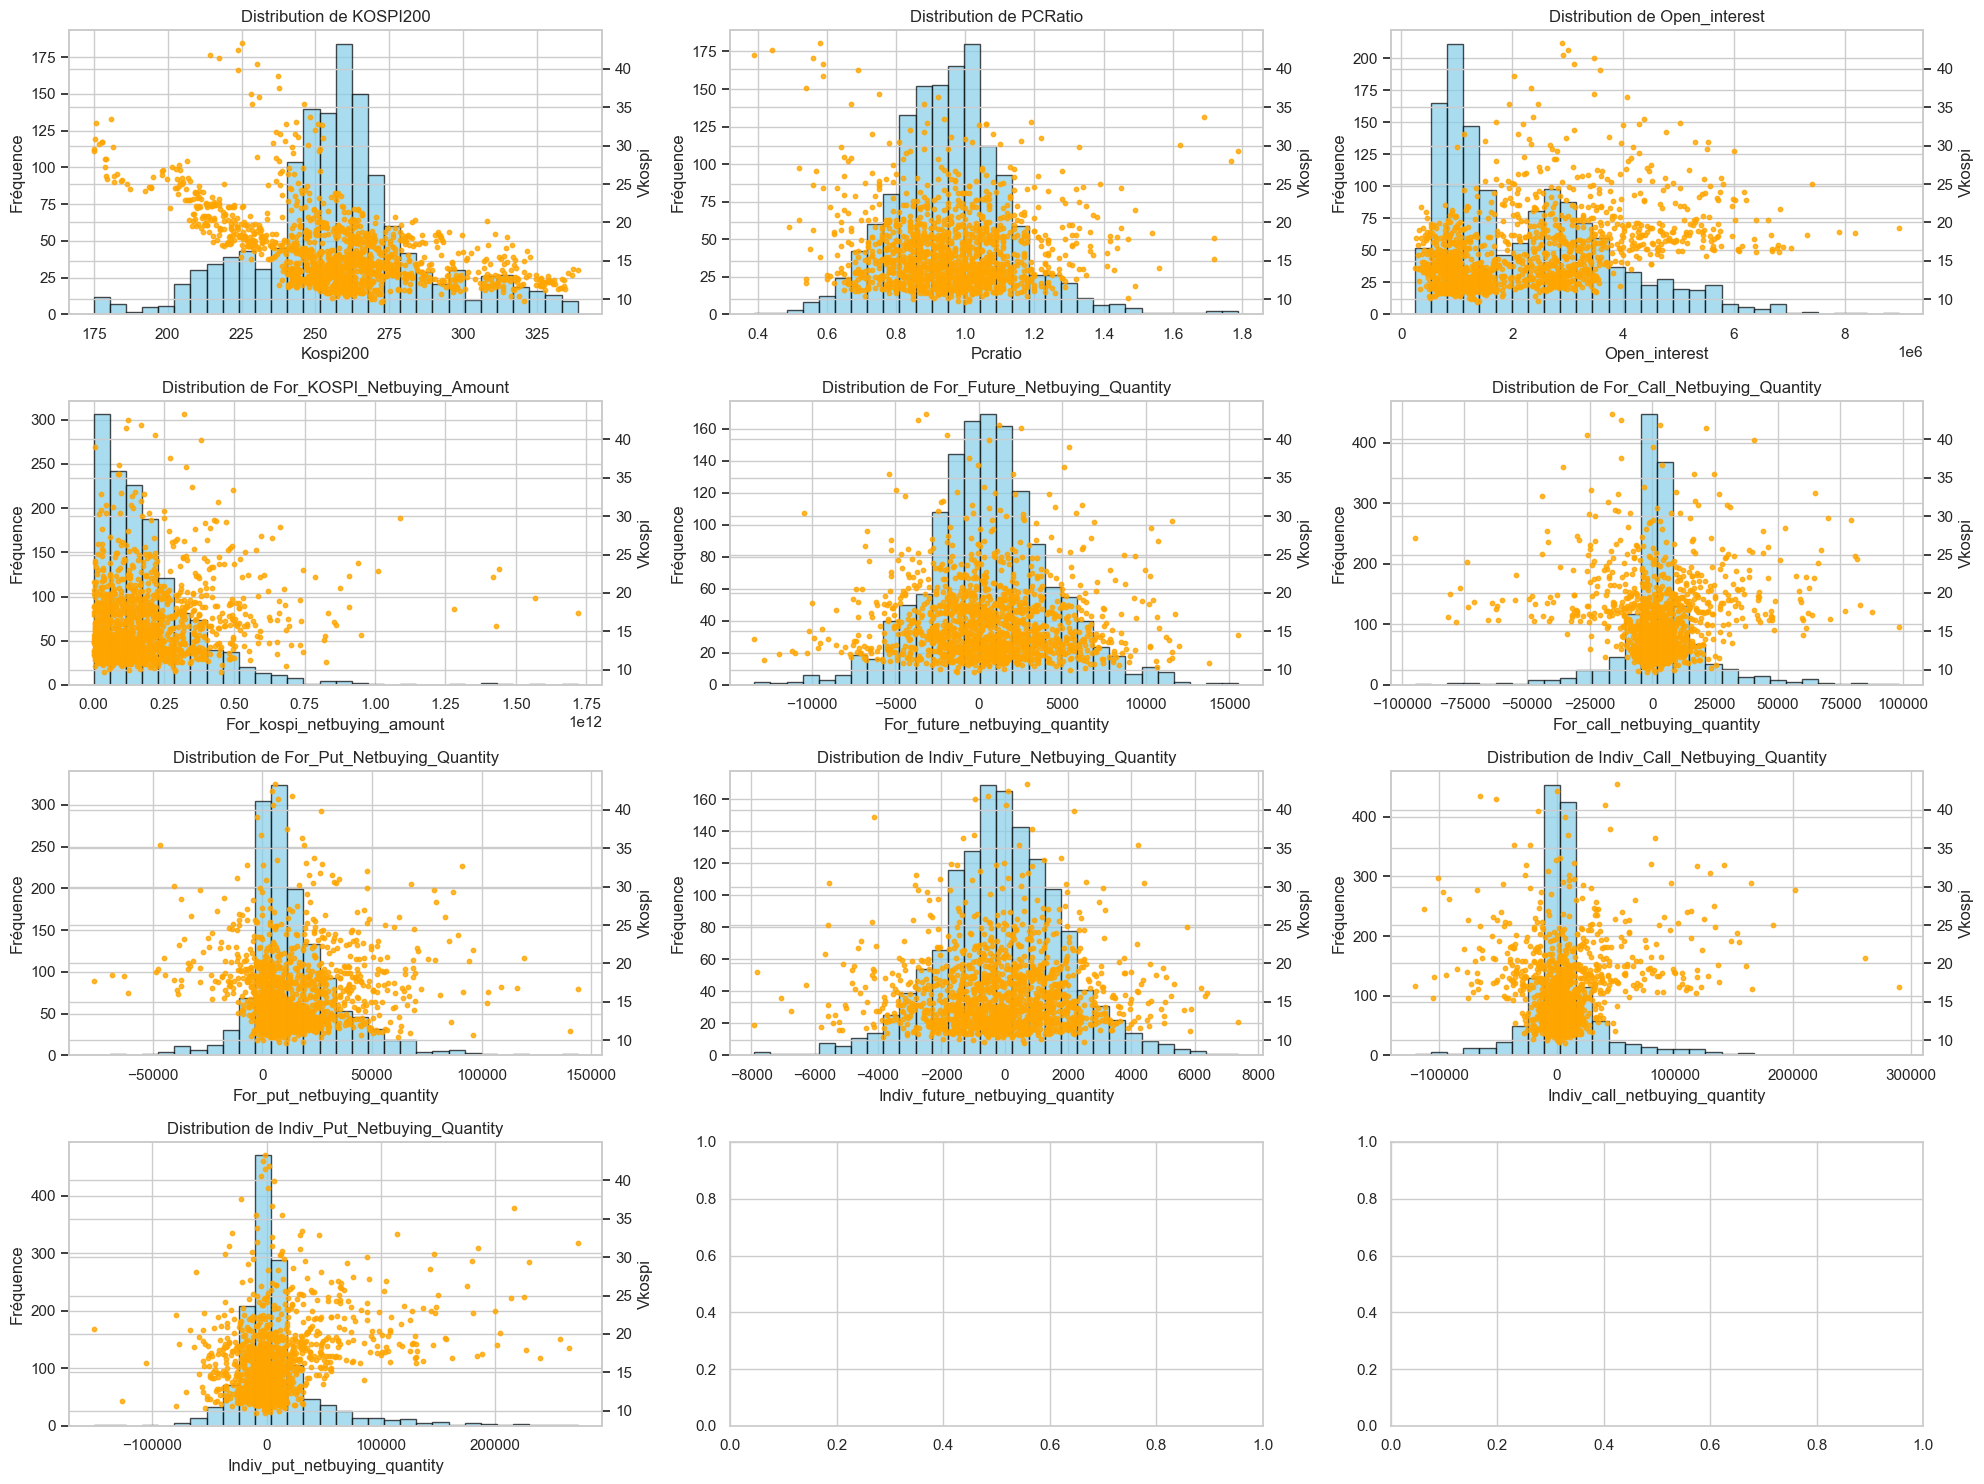

In [63]:
explore_columns_combined(df, columns_to_explore, "VKOSPI")

C'est beaucoup mieux ! On voit qu'on peut être encore plus sévère sur les limites de définition des outliers, mais on pourra ajuster le tir plus tard si on constate que nos métriques ne sont pas assez satisfaisantes.

On va maintenant traiter notre donnée catégorielle : "Day_of_a_week".

Pour étudier la distribution de cette donnée, on va visualiser un violin plot :

In [66]:
def make_violin_plot(column, figsize=(15, 8)):
    plt.figure(figsize=figsize)
    sns.violinplot(data=df, x="price", y=column, inner=None)
    plt.title("Distribution of price in function of %s" % column.capitalize())
    plt.show()

In [67]:
make_violin_plot("Day_of_a_week")

ValueError: Could not interpret value `price` for `x`. An entry with this name does not appear in `data`.

<Figure size 1500x800 with 0 Axes>

On veut également déterminer les variables qui auront une importance (ou non) dans la prédiction. Pour cela, on peut utiliser une matrice de corrélation !

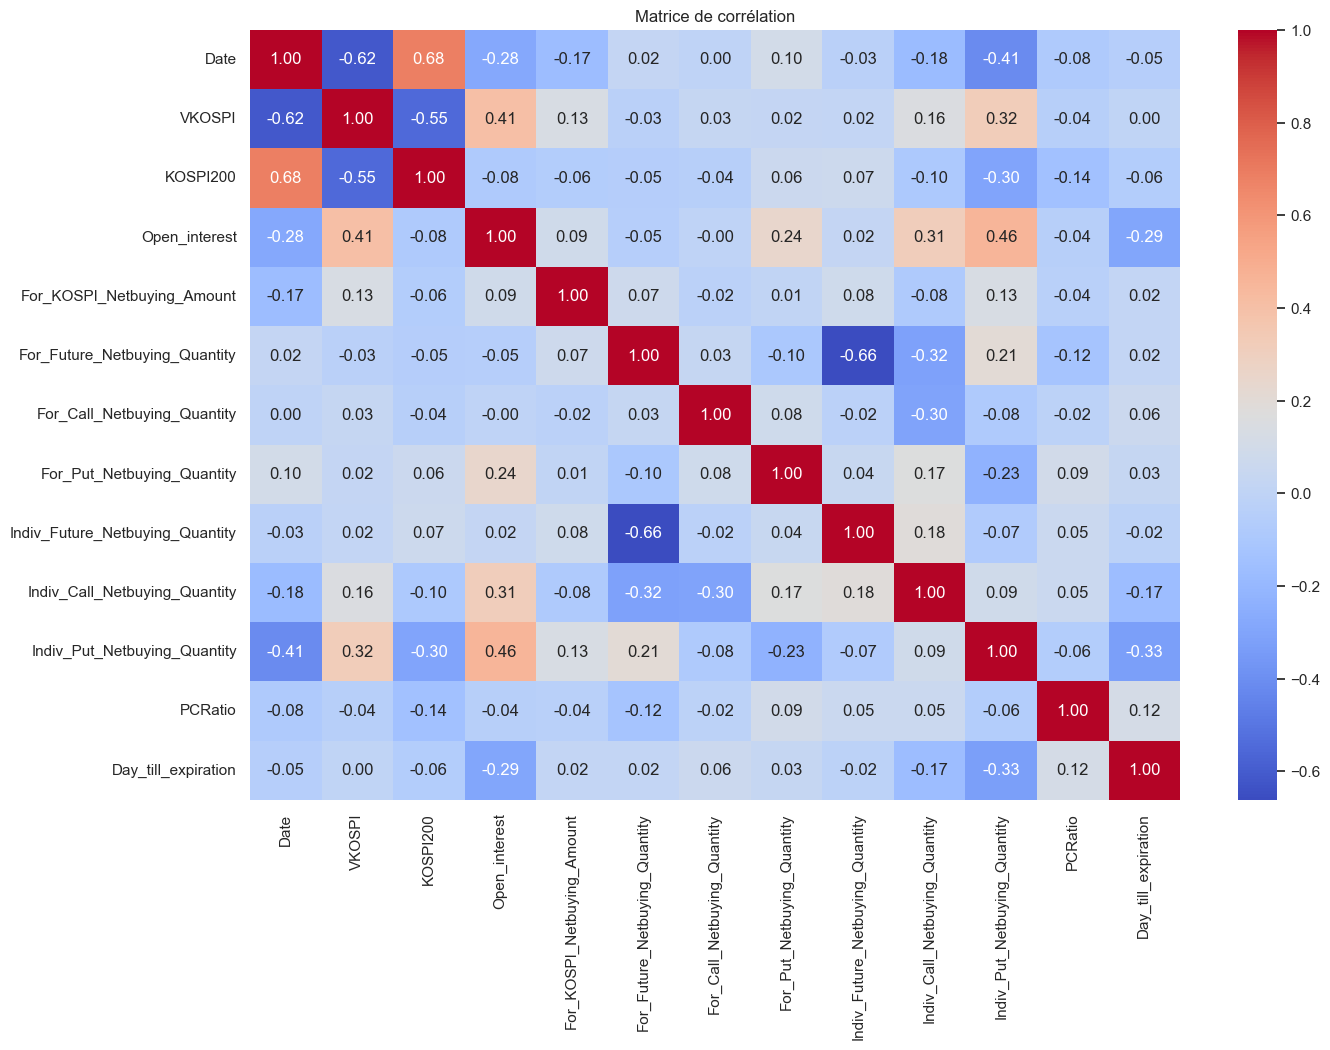

In [64]:
correlation_matrix = df.drop(columns=["Day_of_a_week"]).corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

### **Modélisation**

On va maintenant séparer nos données en un ensemble d'entraînement et de test. Attention cependant car nos données sont indexées par le temps : toute coupure aléatoire est à bannir si on veut éviter de violer l'ordre temporel. D'après la consigne du projet, on va alors former un dataset de test composé des 20% dates les plus récentes.

In [65]:
# Trier les données par date
df_sorted = df.sort_values(by='Date').dropna()

# Séparer les 20% des données les plus récentes pour le test
split_index = int(len(df_sorted) * 0.8)
df_train = df_sorted.iloc[:split_index]
df_test = df_sorted.iloc[split_index:]